In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import tensorflow as tf

In [2]:
import tensorflow as tf
import google.protobuf

print("TensorFlow:", tf.__version__)
print("Protobuf:", google.protobuf.__version__)

TensorFlow: 2.20.0
Protobuf: 5.29.3


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import random

In [4]:
DATASET_PATH=r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\database\PlantVillage"

In [5]:
classes=os.listdir(DATASET_PATH)
print("Total classes",len(classes))
classes

Total classes 15


['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_healthy',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato__Tomato_YellowLeaf__Curl_Virus']

In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [7]:
train_generator=train_datagen.flow_from_directory(DATASET_PATH,target_size=(224,224),
                                                  batch_size=32,class_mode="categorical",
                                                  subset="training",
                                                  shuffle=True)

Found 16516 images belonging to 15 classes.


In [8]:
validation_generator=train_datagen.flow_from_directory(
    DATASET_PATH,target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False)

Found 4122 images belonging to 15 classes.


In [9]:
from tensorflow.keras.applications import MobileNetV2

In [10]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [11]:
base_model.trainable = True

In [12]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [13]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [14]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.3)(x)

predictions = Dense(15, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [15]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=1e-5,
    clipnorm=1.0
)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [17]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [19]:
checkpoint = ModelCheckpoint(
    "models/mobilenetv2_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [21]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

C:\Users\Dhwani Soni\anaconda3\envs\ddddd\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
299/517 ━━━━━━━━━━━━━━━━━━━━ 4:31 1s/step - accuracy: 0.1928 - loss: 2.6068

KeyboardInterrupt: 

In [18]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/mobilenetv2_plant_disease_model_final.keras")

SyntaxError: invalid syntax (4055544704.py, line 5)

In [18]:
import os

os.listdir("models")

['mobilenetv2_plant_disease_model.keras']

In [19]:
print(train_generator.class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [20]:
import json

with open("models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\test_images\tomato_early_blight.jpg", target_size=(224,224))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

print(np.argmax(pred))
print(np.max(pred))

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (238439702.py, line 4)

In [24]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("models/mobilenetv2_plant_disease_model.keras")

img = image.load_img(
    r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\test_images\tomato_early_blight.jpg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)
print("Index:", np.argmax(prediction))
print("Confidence:", np.max(prediction))

C:\Users\Dhwani Soni\anaconda3\envs\ddddd\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Dhwani Soni\\Desktop\\AI_Farming_Assistant\\test_images\\tomato_early_blight.jpg'

In [25]:
import os

os.listdir(r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant")

['.env',
 'app.py',
 'crop_info.py',
 'data',
 'database',
 'disease_info.py',
 'models',
 'notebooks',
 'static',
 'templates',
 'test_images',
 'traning',
 '__pycache__']

In [30]:
os.listdir(r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\test_images")

['potato_healthy.JPG',
 'tomato_early_blight.jpg',
 'tomato_healthy.jpg',
 'tomato_leaf.jpg',
 'tomato_leaf_mold.JPG']

In [29]:
img = image.load_img(
    r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\test_images\tomato_early_blight.jpg",
    target_size=(224,224)
)

In [31]:
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)
print("Index:", np.argmax(prediction))
print("Confidence:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[0.08091698 0.04122843 0.03720821 0.02246646 0.02792835 0.06594173
  0.0256966  0.08813171 0.03579385 0.31303924 0.039933   0.02661997
  0.08655834 0.03119675 0.0773404 ]]
Index: 9
Confidence: 0.31303924


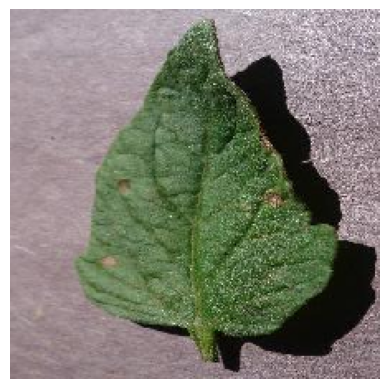

In [32]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.show()

In [33]:
print(train_generator.class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [34]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [35]:
import os

print(os.listdir(r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\database\PlantVillage\Tomato___Early_blight")[:5])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Dhwani Soni\\Desktop\\AI_Farming_Assistant\\database\\PlantVillage\\Tomato___Early_blight'